# Phase 3 — Feature Engineering
### Personal Spending Intelligence System

**What this notebook does:**
Transforms raw monthly transaction totals into meaningful ML-ready features — the actual inputs your model will learn from in Phase 4.

**What you will learn:**
- The `pivot_table` operation
- `pct_change()` — month-over-month change
- `rolling().mean()` — smoothed averages over time
- How to define and separate fixed vs discretionary spending
- How to build a clean, model-ready feature matrix


## Step 1 — Imports

Same libraries as Phase 2. We add nothing new here — good feature engineering
is about transforming data cleverly, not adding complexity.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

df = pd.read_csv('data/transactions.csv', parse_dates=['date'])
df['month'] = df['date'].dt.to_period('M')

expenses = df[df['type'] == 'debit'].copy()
income   = df[df['type'] == 'credit'].copy()

print(f"Loaded {len(df)} transactions")
print(f"Months covered: {df['month'].nunique()}")


Loaded 820 transactions
Months covered: 12


## Step 2 — Feature 1: Monthly category totals (the base table)

Every feature we build starts from one thing: **how much was spent per category per month?**

We create this using `pivot_table` — it reshapes the data so that:
- Each **row** = one month
- Each **column** = one spending category
- Each **cell value** = total spend for that category in that month

This is called **reshaping** or **pivoting** the data. It is one of the most
important data manipulation operations in pandas.

Before pivoting, data is **long** (one row per transaction).
After pivoting, data is **wide** (one row per month, categories as columns).
ML models need wide format — one row = one observation with many features.


In [3]:
# pivot_table aggregates and reshapes in one step
monthly_cat = expenses.pivot_table(
    index='month',         # each unique month becomes a row
    columns='category',    # each unique category becomes a column
    values='amount',       # the numbers to fill the table with
    aggfunc='sum'          # how to combine multiple transactions: sum them
).fillna(0)                # months with no spend in a category get 0, not NaN

# Also compute monthly income total
monthly_income = income.groupby('month')['amount'].sum()

print("Shape of monthly pivot table:", monthly_cat.shape)
print("Rows = months, Columns = categories")
print()
monthly_cat.head()


Shape of monthly pivot table: (12, 10)
Rows = months, Columns = categories



category,Coffee & Snacks,Entertainment,Food and Dining,Groceries,Health & Fitness,Rent,Shopping,Subscriptions,Transport,Utilities
month,,,,,,,,,,
2024-01,2290,680,3650,6310,2160,18000,2420,620,3410,2840
2024-02,2190,780,3690,6610,2770,36000,3030,660,3810,910
2024-03,2530,430,4070,6360,1990,36000,3480,620,4120,2600
2024-04,2220,2030,5420,6320,1960,18000,4930,840,3600,970
2024-05,2670,890,4890,5080,2720,18000,4610,810,4360,2010


## Step 3 — Feature 2: Month-over-month (MoM) % change

`pct_change()` computes: (this month - last month) / last month × 100

This tells the model **direction and magnitude of change** — not just the absolute number.
Example: Food spending of Rs.4200 this month is only meaningful when you know it was Rs.3100 last month (+35% — that is a spike worth flagging).

The first month will always be `NaN` (no previous month to compare to).
We fill NaN with 0 — meaning "no change from baseline" for the first observation.

`pct_change()` is a **time-series** operation. It only makes sense on data that
is ordered chronologically — which our pivot table already is (months are sorted).


In [4]:

# pct_change() works column by column, comparing each row to the previous row
mom_change = monthly_cat.pct_change() * 100
# Multiply by 100 to express as percentage (0.35 -> 35.0)

mom_change = mom_change.fillna(0).round(1)
# fillna(0): first month has no previous month, so we treat it as 0% change
# round(1): keep one decimal place — 35.2%, not 35.19273...

# Rename columns to make it clear these are change features, not raw totals
mom_change.columns = [f"{col}_mom_pct" for col in mom_change.columns]
# f-string in a list comprehension: for each column name, add '_mom_pct' suffix
# e.g. 'Food & Dining' becomes 'Food & Dining_mom_pct'

print("Month-over-month % change (first 3 months, select columns):")
display_cols = [c for c in mom_change.columns if any(x in c for x in ['Food', 'Shopping', 'Transport'])]
print(mom_change[display_cols].head(4).to_string())


Month-over-month % change (first 3 months, select columns):
         Food and Dining_mom_pct  Shopping_mom_pct  Transport_mom_pct
month                                                                
2024-01                      0.0               0.0                0.0
2024-02                      1.1              25.2               11.7
2024-03                     10.3              14.9                8.1
2024-04                     33.2              41.7              -12.6


## Step 4 — Feature 3: Rolling 3-month average

A **rolling average** (also called a moving average) smooths out short-term spikes
by averaging over a window of recent months.

`rolling(window=3).mean()` means: for each month, take the average of
that month and the 2 months before it.

Why does this matter?
- Raw spend: Jan=3000, Feb=8000 (party), Mar=3200
- Rolling avg: Jan=NaN, Feb=NaN, Mar=4733

The model sees 4733, not 8000. The spike is dampened.
This stops one unusual month from making the model think high spending is normal.

The first two months will be NaN (not enough history for a 3-month window).
We fill these with the raw value — best guess when we have no history.


In [8]:
# rolling(window=3) creates a sliding window of 3 rows
# .mean() averages the values in each window
rolling_avg = monthly_cat.rolling(window=3, min_periods=1).mean().round(0)
# min_periods=1 means: if fewer than 3 months of history exist, use whatever is available
# Without min_periods=1, the first 2 rows would be NaN entirely

rolling_avg.columns = [f"{col}_rolling3m" for col in rolling_avg.columns]

print("Rolling 3-month average (Food and Dining):")
comparison = pd.DataFrame({
    'raw_spend':    monthly_cat['Food and Dining'],
    'rolling_3m':   rolling_avg['Food and Dining_rolling3m']
})
print(comparison.to_string())


Rolling 3-month average (Food and Dining):
         raw_spend  rolling_3m
month                         
2024-01       3650      3650.0
2024-02       3690      3670.0
2024-03       4070      3803.0
2024-04       5420      4393.0
2024-05       4890      4793.0
2024-06       3170      4493.0
2024-07       4560      4207.0
2024-08       4330      4020.0
2024-09       4630      4507.0
2024-10       4990      4650.0
2024-11       4690      4770.0
2024-12       5160      4947.0


## Step 5 — Feature 4: Category spend as % of monthly income

Raw amounts are less informative than proportions.
Spending Rs.5000 on food means different things depending on your income.

For each category, we compute:
`(category_total / monthly_income) * 100`

This normalises all spending relative to income — a much fairer comparison
across months (and later, across users if this becomes a real app).

This is called **normalisation** — scaling values to a common reference point.
It is one of the most important preprocessing steps in machine learning.


In [9]:
# Divide each row of monthly_cat by the income for that month
# monthly_income is a Series indexed by month — pandas aligns by index automatically
cat_pct_income = monthly_cat.div(monthly_income, axis=0) * 100
# .div(x, axis=0): divide each ROW by the corresponding income value
# axis=0 means align on rows (months), not columns

cat_pct_income = cat_pct_income.round(2)
cat_pct_income.columns = [f"{col}_pct_income" for col in cat_pct_income.columns]

print("Category spend as % of monthly income (select categories, first 4 months):")
display_cols = [c for c in cat_pct_income.columns if any(x in c for x in ['Rent', 'Food', 'Coffee', 'Shopping'])]
print(cat_pct_income[display_cols].head(4).to_string())


Category spend as % of monthly income (select categories, first 4 months):
         Coffee & Snacks_pct_income  Food and Dining_pct_income  Rent_pct_income  Shopping_pct_income
month                                                                                                
2024-01                        3.52                        5.62            27.69                 3.72
2024-02                        3.37                        5.68            55.38                 4.66
2024-03                        3.89                        6.26            55.38                 5.35
2024-04                        3.42                        8.34            27.69                 7.58


## Step 6 — Feature 5: Monthly savings rate (the target variable)

The **target variable** (also called label or y) is what the ML model will predict.
In Phase 4, we will train a model to predict next month's savings rate based on
this month's spending patterns.

Savings rate = (income - total expenses) / income × 100

This is the most important number in the whole project — the north-star metric
that every other feature feeds into.


In [10]:
monthly_total_expense = expenses.groupby('month')['amount'].sum()

savings_rate = ((monthly_income - monthly_total_expense) / monthly_income * 100).round(2)
savings_rate.name = 'savings_rate'

print("Monthly savings rate (%):")
for month, rate in savings_rate.items():
    bar = '#' * int(rate / 2)
    status = 'good' if rate >= 20 else 'ok' if rate >= 10 else 'low'
    print(f"  {str(month)}  {rate:5.1f}%  {bar:<25}  [{status}]")

print(f"Average savings rate: {savings_rate.mean():.1f}%")
print(f"Target for healthy personal finance: 20%+")


Monthly savings rate (%):
  2024-01   34.8%  #################          [good]
  2024-02    7.0%  ###                        [low]
  2024-03    4.3%  ##                         [low]
  2024-04   28.8%  ##############             [good]
  2024-05   29.2%  ##############             [good]
  2024-06    3.6%  #                          [low]
  2024-07   33.8%  ################           [good]
  2024-08   32.5%  ################           [good]
  2024-09   29.2%  ##############             [good]
  2024-10   28.5%  ##############             [good]
  2024-11   27.3%  #############              [good]
  2024-12   34.8%  #################          [good]
Average savings rate: 24.5%
Target for healthy personal finance: 20%+


## Step 7 — Feature 6: Fixed vs discretionary spend ratio

Not all spending is equal. Some costs are **fixed** — they happen every month
regardless of your choices (rent, utilities, subscriptions).
Others are **discretionary** — choices you actively make (restaurants, shopping, entertainment).

The ratio of discretionary to fixed spend tells the model how much financial
flexibility exists. A person with 80% fixed costs has very little room to cut
spending in a bad month.

This is called **domain knowledge** — you are encoding your understanding of
personal finance into the feature itself. This is what separates good data
scientists from people who just run algorithms.


In [12]:
FIXED_CATEGORIES        = ['Rent', 'Utilities', 'Subscriptions']
DISCRETIONARY_CATEGORIES = ['Food and Dining', 'Coffee & Snacks', 'Shopping',
                             'Entertainment', 'Health & Fitness', 'Transport']

# Sum across only the fixed categories for each month (axis=1 means sum across columns)
fixed_spend        = monthly_cat[FIXED_CATEGORIES].sum(axis=1)
discretionary_spend = monthly_cat[DISCRETIONARY_CATEGORIES].sum(axis=1)

# Ratio: how many rupees of discretionary for every rupee of fixed
disc_to_fixed_ratio = (discretionary_spend / fixed_spend).round(3)
disc_to_fixed_ratio.name = 'disc_to_fixed_ratio'

print("Fixed vs Discretionary spend by month:")
summary = pd.DataFrame({
    'fixed':        fixed_spend.astype(int),
    'discretionary': discretionary_spend.astype(int),
    'ratio':        disc_to_fixed_ratio
})
print(summary.to_string())
print(f"Average ratio: {disc_to_fixed_ratio.mean():.2f}")
print("(A ratio of 1.0 means you spend equally on fixed and discretionary)")


Fixed vs Discretionary spend by month:
         fixed  discretionary  ratio
month                               
2024-01  21460          14610  0.681
2024-02  37570          16270  0.433
2024-03  39220          16620  0.424
2024-04  19810          20160  1.018
2024-05  20820          20140  0.967
2024-06  37760          18710  0.495
2024-07  20790          16570  0.797
2024-08  20430          17320  0.848
2024-09  21710          17460  0.804
2024-10  21160          17150  0.810
2024-11  19180          21210  1.106
2024-12  19550          17730  0.907
Average ratio: 0.77
(A ratio of 1.0 means you spend equally on fixed and discretionary)


## Step 8 — Assemble the full feature matrix

Now we bring all 6 feature groups together into one clean DataFrame.
This is called the **feature matrix** — the final input to the ML model.

Convention:
- `X` = features (inputs to the model)
- `y` = target variable (what the model predicts)

Every ML tutorial and textbook uses X and y — it is universal notation.


In [13]:
# Combine all feature groups side by side (axis=1 = join on columns)
feature_matrix = pd.concat([
    monthly_cat,           # raw monthly totals per category
    mom_change,            # month-over-month % change
    rolling_avg,           # rolling 3-month smoothed average
    cat_pct_income,        # category as % of income
    disc_to_fixed_ratio,   # discretionary vs fixed ratio
    savings_rate           # target variable
], axis=1)

# Drop the first row — rolling averages make the first month unreliable
feature_matrix = feature_matrix.iloc[1:].reset_index()

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"  {feature_matrix.shape[0]} monthly observations")
print(f"  {feature_matrix.shape[1]} columns (features + target)")
print()
print("Column groups:")
print(f"  Raw totals       : {len(monthly_cat.columns)} columns")
print(f"  MoM change       : {len(mom_change.columns)} columns")
print(f"  Rolling 3m avg   : {len(rolling_avg.columns)} columns")
print(f"  % of income      : {len(cat_pct_income.columns)} columns")
print(f"  Disc/fixed ratio : 1 column")
print(f"  Savings rate (y) : 1 column")
print()

# X = all columns except the target
# y = savings_rate column only
X = feature_matrix.drop(columns=['savings_rate', 'month'])
y = feature_matrix['savings_rate']

print(f"X shape (features): {X.shape}")
print(f"y shape (target)  : {y.shape}")


Feature matrix shape: (11, 43)
  11 monthly observations
  43 columns (features + target)

Column groups:
  Raw totals       : 10 columns
  MoM change       : 10 columns
  Rolling 3m avg   : 10 columns
  % of income      : 10 columns
  Disc/fixed ratio : 1 column
  Savings rate (y) : 1 column

X shape (features): (11, 41)
y shape (target)  : (11,)


## Step 9 — Which features correlate most with savings rate?

**Correlation** measures how strongly two variables move together:
- +1.0 = perfect positive correlation (both go up together)
-  0.0 = no relationship
- -1.0 = perfect negative correlation (one goes up, other goes down)

We look at how each feature correlates with `savings_rate`.
High absolute correlation = that feature will be useful to the model.
This is called **feature selection** — understanding which features matter before training.


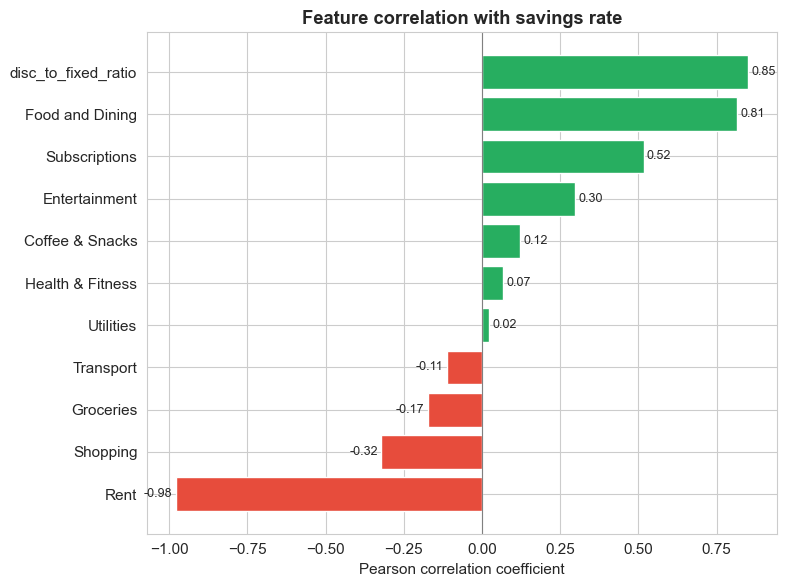

Most negatively correlated (these hurt savings rate):
Rent        -0.979389
Shopping    -0.322471
Groceries   -0.173749
Most positively correlated (these help savings rate):
Subscriptions          0.516574
Food and Dining        0.814911
disc_to_fixed_ratio    0.851377


In [14]:
# Compute correlation of every column with savings_rate
# We use only raw category totals + ratio features to keep it readable
key_cols = list(monthly_cat.columns) + ['disc_to_fixed_ratio', 'savings_rate']
corr_with_target = (
    feature_matrix[key_cols]
    .corr()['savings_rate']       # correlation of every column with savings_rate
    .drop('savings_rate')          # drop self-correlation (always 1.0)
    .sort_values()                 # sort from most negative to most positive
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(x=0, color='gray', linewidth=0.8)
ax.set_title('Feature correlation with savings rate', fontweight='bold')
ax.set_xlabel('Pearson correlation coefficient')

for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Most negatively correlated (these hurt savings rate):")
print(corr_with_target.head(3).to_string())
print("Most positively correlated (these help savings rate):")
print(corr_with_target.tail(3).to_string())


## Step 10 — Save the feature matrix

We save two files:
- `features_X.csv` — the feature matrix (inputs to the model)
- `features_y.csv` — the target variable (what the model predicts)

Phase 4 will load these directly and train the ML model.


In [15]:
import os
os.makedirs('data', exist_ok=True)

X.to_csv('data/features_X.csv', index=False)
y.to_csv('data/features_y.csv', index=False)

print("Saved:")
print(f"  data/features_X.csv  — {X.shape[0]} rows x {X.shape[1]} features")
print(f"  data/features_y.csv  — {y.shape[0]} savings rate values")
print()
print("Next step: Phase 4 — ML Models")
print("  We will train a regression model to predict next month's savings rate")
print("  using these features as input.")


Saved:
  data/features_X.csv  — 11 rows x 41 features
  data/features_y.csv  — 11 savings rate values

Next step: Phase 4 — ML Models
  We will train a regression model to predict next month's savings rate
  using these features as input.
